# Analytics Project

In [1]:
# import important libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import re 
from scipy import stats
from datetime import datetime

# Plot style 
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

In [2]:
import os 
fp = str(os.getcwd())
print(fp)

C:\Users\cyril


In [3]:
# Load dataset into dataframe 
# Read files 
txn_data = pd.read_csv(fp + "\\QVI_transaction_data1.csv")
cust_data = pd.read_csv(fp + "\\QVI_purchase_behaviour1.csv")

In [4]:
txn_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,17/10/2018,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,14/05/2019,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,20/05/2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,17/08/2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,18/08/2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,09/03/2019,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,13/08/2018,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,06/11/2018,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,27/12/2018,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [5]:
cust_data

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [6]:
# Checking length of dataset
len_txn = len(txn_data)
len_txn

264836

In [7]:
# Checking length of dataset
len_cust = len(cust_data)
len_cust

72637

In [8]:
# Inspect data 
t_inf = txn_data.info()
t_inf

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  object 
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 16.2+ MB


In [9]:
txn_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,17/10/2018,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,14/05/2019,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,20/05/2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,17/08/2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,18/08/2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,19/05/2019,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,16/05/2019,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,16/05/2019,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,20/08/2018,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,18/08/2018,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [10]:
c_inf = cust_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [11]:
cust_data.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [12]:
# Print the earliest and latest dates in the 'DATE' column 
print("Date range:", txn_data['DATE'].min(), "to", txn_data['DATE'].max())

Date range: 01/01/2019 to 31/12/2018


In [13]:
# Ensure PROD_NAME exist
if 'PROD_NAME' not in txn_data.columns:
    raise KeyError("PROD_NAME column not found in transactionData. Please check CSV columns.")
    
txn_data['PROD_NAME_LOWER'] = txn_data['PROD_NAME'].astype(str).str.lower()

# Split into words and build frequency
words = txn_data['PROD_NAME_LOWER'].str.replace(r'[^a-z0-9\s]', ' ', regex=True).str.split()
all_words = [w for sub in words.dropna() for w in sub] 
word_freq = pd.Series(all_words).value_counts().reset_index()
word_freq.columns = ['word', 'count']
print("\nTop product words:\n", word_freq.head(40))


Top product words:
          word  count
0        175g  60561
1       chips  49770
2        150g  43131
3      kettle  41288
4      smiths  28860
5        salt  27976
6      cheese  27890
7        134g  25102
8    pringles  25102
9     doritos  24962
10    crinkle  23960
11       110g  22387
12       corn  22063
13   original  21560
14        cut  20754
15       chip  18645
16       170g  18502
17      salsa  18094
18      cream  15465
19    chicken  15407
20     chilli  15390
21       165g  15297
22        sea  14145
23      thins  14075
24       sour  13882
25     crisps  12607
26       330g  12540
27    vinegar  12402
28       300g  12041
29        rrd  11894
30      sweet  11060
31  infuzions  11057
32    supreme  10963
33     chives  10951
34         ww  10320
35       popd   9693
36       cobs   9693
37   tortilla   9580
38   tostitos   9471
39   twisties   9454


In [14]:
# Remove salsa products
txn_data = txn_data[~txn_data['PROD_NAME_LOWER'].str.contains('salsa', na=False)].copy()
print("Rows after removing 'salsa products:", len(txn_data))

Rows after removing 'salsa products: 246742


In [15]:
# Summary and detect outliers in quantity (PROD_QTY)

#Ensure PROD_QTY column exists
if 'PROD_QTY' not in txn_data.columns:
    raise KeyError("PROD_QTY column not found in txn_data.")

# View summary statistics for quantity
print(txn_data['PROD_QTY'].describe())

# Filter rows where quantity is >= 200
outliers_200 = txn_data[txn_data['PROD_QTY'] >=200].copy()

# Number of such rows 
print("Rows with PROD_QTY >= 200: ", len(outliers_200))

# Preview the outlier rows
display(outliers_200.head(10))

count    246742.000000
mean          1.908062
std           0.659831
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64
Rows with PROD_QTY >= 200:  2


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_LOWER
69762,19/08/2018,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,dorito corn chp supreme 380g
69763,20/05/2019,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,dorito corn chp supreme 380g


In [16]:
# Define priority columns 
qty_col = 'PROD_QTY'
loyalty_col = 'LYLTY_CARD_NBR'
pp = txn_data[txn_data[loyalty_col] == 226000]
pp

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_LOWER
69762,19/08/2018,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,dorito corn chp supreme 380g
69763,20/05/2019,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,dorito corn chp supreme 380g


In [17]:
# Define priority columns 
qty_col = 'PROD_QTY'
loyalty_col = 'LYLTY_CARD_NBR'

# Find customers who bought 200 or more chips in a transaction 
customers_to_drop = txn_data.loc[
    txn_data[qty_col] >= 200,
    loyalty_col
].unique() 

print("Customers to drop (high-qty):", customers_to_drop)

# Remove all transactions from these customers 
txn_data = txn_data[
    ~txn_data[loyalty_col].isin(customers_to_drop)
].copy()

print("Rows after dropping those customers:", len(txn_data))


Customers to drop (high-qty): [226000]
Rows after dropping those customers: 246740


In [18]:
customers_to_drop

array([226000], dtype=int64)

In [19]:
pp = txn_data[txn_data[loyalty_col] == 226000]
pp


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_LOWER


In [20]:
txn_data['DATE'].dtype

dtype('O')

In [21]:

# Count number of transaction lines per DATE to see if any dates are missing
txn_by_day = txn_data.groupby('DATE').size().reset_index(name='N').sort_values('DATE')

# Ensure DATE is datetime in txn_by_day
txn_by_day['DATE'] = pd.to_datetime(txn_by_day['DATE'])

print("Distinct dates:", len(txn_by_day))

display(txn_by_day.head(10))

# Generate full date range 1 July 2018 -> 30 June 2019
full_range = pd.DataFrame({'DATE': pd.date_range(start='2018-07-01', end='2019-06-30')})

txn_by_day_full = full_range.merge(txn_by_day, on='DATE', how='left').fillna({'N':0})

print('Full range rows:', len(txn_by_day_full))

Distinct dates: 364


C:\Users\cyril\AppData\Local\Temp\ipykernel_49716\197482624.py:5: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  txn_by_day['DATE'] = pd.to_datetime(txn_by_day['DATE'])


,DATE,N
0,2019-01-01,634
1,2019-01-02,708
2,2019-01-03,670
3,2019-01-04,635
4,2019-01-05,643
5,2019-01-06,682
6,2018-01-07,663
7,2018-01-08,680
8,2018-01-09,687
9,2018-01-10,662


Full range rows: 365


In [22]:
display(txn_by_day.head(30))

,DATE,N
0,2019-01-01,634
1,2019-01-02,708
2,2019-01-03,670
3,2019-01-04,635
4,2019-01-05,643
5,2019-01-06,682
6,2018-01-07,663
7,2018-01-08,680
8,2018-01-09,687
9,2018-01-10,662


In [23]:
display(txn_by_day.tail(30))

,DATE,N
334,2018-12-28,669
335,2019-01-29,667
336,2019-03-29,699
337,2019-04-29,697
338,2019-05-29,714
339,2019-06-29,703
340,2018-07-29,659
341,2018-08-29,666
342,2018-09-29,671
343,2018-10-29,666


In [24]:
print(txn_by_day_full)

          DATE      N
0   2018-07-01    0.0
1   2018-07-02    0.0
2   2018-07-03    0.0
3   2018-07-04    0.0
4   2018-07-05    0.0
..         ...    ...
360 2019-06-26  657.0
361 2019-06-27  669.0
362 2019-06-28  673.0
363 2019-06-29  703.0
364 2019-06-30  704.0

[365 rows x 2 columns]


In [25]:
zero_txn_days = txn_by_day_full[
    txn_by_day_full['N'] == 0
]

len(zero_txn_days)

73

In [26]:
print(txn_by_day_full.head(30))

         DATE      N
0  2018-07-01    0.0
1  2018-07-02    0.0
2  2018-07-03    0.0
3  2018-07-04    0.0
4  2018-07-05    0.0
5  2018-07-06    0.0
6  2018-07-07  695.0
7  2018-07-08  668.0
8  2018-07-09  663.0
9  2018-07-10  644.0
10 2018-07-11  679.0
11 2018-07-12  672.0
12 2018-07-13  727.0
13 2018-07-14  661.0
14 2018-07-15  712.0
15 2018-07-16  678.0
16 2018-07-17  694.0
17 2018-07-18  689.0
18 2018-07-19  637.0
19 2018-07-20  684.0
20 2018-07-21  683.0
21 2018-07-22  673.0
22 2018-07-23  673.0
23 2018-07-24  648.0
24 2018-07-25  674.0
25 2018-07-26  672.0
26 2018-07-27  697.0
27 2018-07-28  640.0
28 2018-07-29  659.0
29 2018-07-30  692.0


In [27]:
print(txn_by_day_full.tail(30))

          DATE      N
335 2019-06-01  673.0
336 2019-06-02  666.0
337 2019-06-03  661.0
338 2019-06-04  681.0
339 2019-06-05  707.0
340 2019-06-06  700.0
341 2019-06-07    0.0
342 2019-06-08    0.0
343 2019-06-09    0.0
344 2019-06-10    0.0
345 2019-06-11    0.0
346 2019-06-12    0.0
347 2019-06-13  607.0
348 2019-06-14  743.0
349 2019-06-15  724.0
350 2019-06-16  690.0
351 2019-06-17  658.0
352 2019-06-18  639.0
353 2019-06-19  662.0
354 2019-06-20  698.0
355 2019-06-21  716.0
356 2019-06-22  643.0
357 2019-06-23  653.0
358 2019-06-24  612.0
359 2019-06-25  696.0
360 2019-06-26  657.0
361 2019-06-27  669.0
362 2019-06-28  673.0
363 2019-06-29  703.0
364 2019-06-30  704.0


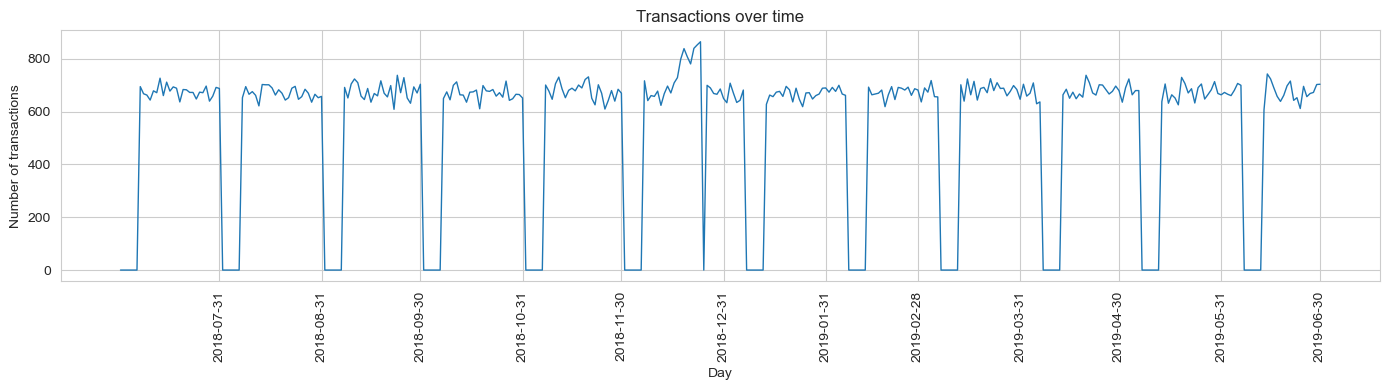

In [28]:
# Plot a line chart: transactions per day, with monthly x-axis ticks. 
plt.figure(figsize=(14,4))
plt.plot(txn_by_day_full['DATE'], txn_by_day_full['N'], linewidth=1)
plt.title('Transactions over time')
plt.xlabel('Day')
plt.ylabel('Number of transactions')
plt.xticks(pd.date_range(start='2018-07-01', end='2019-06-30', freq='1M'), rotation=90)
plt.tight_layout()
plt.show()

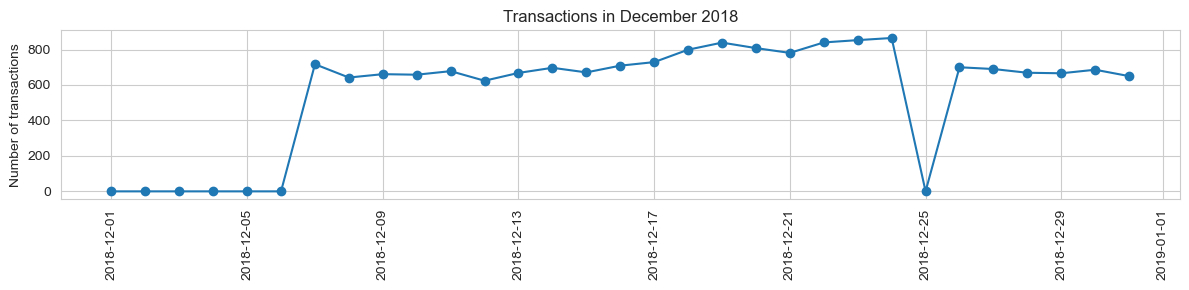

In [29]:
# Analysing Zero sales days in December
mask_dec = (txn_by_day_full['DATE'] >= '2018-12-01') & (txn_by_day_full['DATE'] <= '2018-12-31')
plt.figure(figsize=(12,3))
plt.plot(txn_by_day_full.loc[mask_dec, 'DATE'], txn_by_day_full.loc[mask_dec, 'N'], marker='o')
plt.title('Transactions in December 2018')
plt.xticks(rotation=90)
plt.ylabel('Number of transactions')
plt.tight_layout()
plt.show()

In [30]:
# We use regex to find the first number in the product name and interpret it as grams.

def digit_extxn(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r'(\d+)', str(s))
    return int(m.group(1)) if m else np.nan

txn_data['PACK_SIZE'] = txn_data['PROD_NAME'].apply(digit_extxn)
display(txn_data['PACK_SIZE'].value_counts(dropna=False).sort_index().head(30))   

70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    40203
160     2970
165    15297
170    19983
175    66390
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6416
Name: PACK_SIZE, dtype: int64

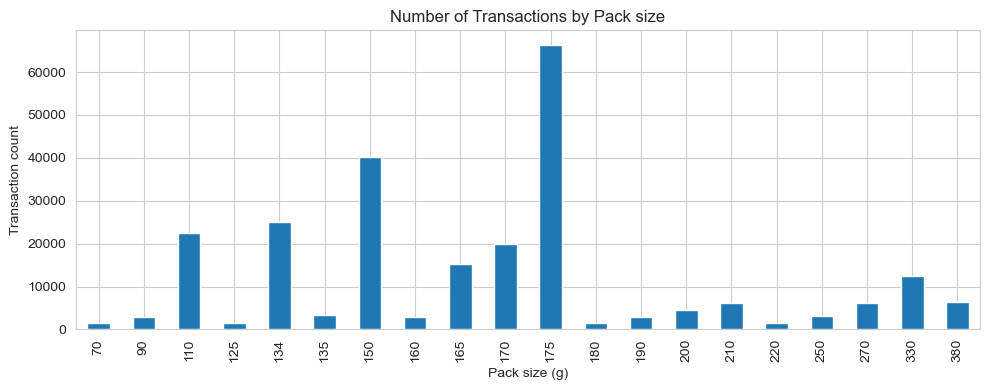

In [31]:
# Plot frequency of PACK_SIZE values (bars)
plt.figure(figsize=(10,4))
txn_data['PACK_SIZE'].dropna().astype(int).value_counts().sort_index().plot(kind='bar')
plt.title('Number of Transactions by Pack size')
plt.xlabel('Pack size (g)')
plt.ylabel('Transaction count')
plt.tight_layout()
plt.show()

In [32]:
#  extract brand by splitting product name and taking first token.
txn_data['BRAND'] = txn_data['PROD_NAME_LOWER'].str.split().str[0]

# Trim punctuation possibly attached
txn_data['BRAND'] = txn_data['BRAND'].str.replace(r'[^a-z0-9]', '', regex=True)

print("Top brands \n", txn_data['BRAND'].value_counts(30))


Top brands 
 kettle        0.167334
smiths        0.111008
pringles      0.101735
doritos       0.089329
thins         0.057044
rrd           0.048205
infuzions     0.044812
ww            0.041825
cobs          0.039284
tostitos      0.038385
twisties      0.038316
tyrrells      0.026108
grain         0.025419
natural       0.024520
cheezels      0.018655
ccs           0.018445
red           0.017942
dorito        0.012900
infzns        0.012742
smith         0.012009
cheetos       0.011863
snbts         0.006387
burger        0.006339
woolworths    0.006144
grnwves       0.005950
sunbites      0.005804
ncc           0.005751
french        0.005747
Name: BRAND, dtype: float64


In [33]:
# Clean brand names (merge variants)

brand_mapping = {
    'red':'rrd',
    'rrd':'rrd',
    'smith':'smiths',
    'smiths':'smiths',
    'dorito':'doritos',
    'doritos':'doritos',
    'infzns':'infuzions',
    'infuzions':'infuzions',
    'snbts':'sunbites',
    'sunbites':'sunbites'
}

# Apply mapping to 'BRAND' column 
txn_data['BRAND_CLEAN'] = txn_data['BRAND'].replace(brand_mapping)

txn_data['BRAND_CLEAN'] = txn_data['BRAND_CLEAN'].fillna(txn_data['BRAND'])

print("Top brands: \n", txn_data['BRAND_CLEAN'].value_counts().head(30))

Top brands: 
 kettle        41288
smiths        30353
doritos       25224
pringles      25102
rrd           16321
infuzions     14201
thins         14075
ww            10320
cobs           9693
tostitos       9471
twisties       9454
tyrrells       6442
grain          6272
natural        6050
cheezels       4603
ccs            4551
sunbites       3008
cheetos        2927
burger         1564
woolworths     1516
grnwves        1468
ncc            1419
french         1418
Name: BRAND_CLEAN, dtype: int64


In [34]:
# Merge the two datasets or dataframes txn_data and cust_data
merged_data = pd.merge(txn_data, cust_data, on='LYLTY_CARD_NBR', how='left')

In [35]:
merged_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_LOWER,PACK_SIZE,BRAND,BRAND_CLEAN,LIFESTAGE,PREMIUM_CUSTOMER
0,17/10/2018,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,natural chip compny seasalt175g,175,natural,natural,YOUNG SINGLES/COUPLES,Premium
1,14/05/2019,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,ccs nacho cheese 175g,175,ccs,ccs,MIDAGE SINGLES/COUPLES,Budget
2,20/05/2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,smiths crinkle cut chips chicken 170g,170,smiths,smiths,MIDAGE SINGLES/COUPLES,Budget
3,17/08/2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,smiths chip thinly s/cream&onion 175g,175,smiths,smiths,MIDAGE SINGLES/COUPLES,Budget
4,18/08/2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,kettle tortilla chpshny&jlpno chili 150g,150,kettle,kettle,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246735,09/03/2019,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,kettle sweet chilli and sour cream 175g,175,kettle,kettle,YOUNG SINGLES/COUPLES,Premium
246736,13/08/2018,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,tostitos splash of lime 175g,175,tostitos,tostitos,YOUNG SINGLES/COUPLES,Premium
246737,06/11/2018,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,doritos mexicana 170g,170,doritos,doritos,YOUNG SINGLES/COUPLES,Premium
246738,27/12/2018,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,doritos corn chip mexican jalapeno 150g,150,doritos,doritos,YOUNG SINGLES/COUPLES,Premium


In [38]:
# Check for unmatched transactions (nulls in joined customer columns)
missing_customers = merged_data[['LIFESTAGE','PREMIUM_CUSTOMER']].isnull().all(axis=1).sum()

print("transactions without matched customer info:", missing_customers)

transactions without matched customer info: 0


In [39]:
# Save merged dataset (optional)
merged_data.to_csv('data.csv', index=False)

In [40]:
import os 
os.getcwd()

'C:\\Users\\cyril'

In [41]:
merged_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_LOWER,PACK_SIZE,BRAND,BRAND_CLEAN,LIFESTAGE,PREMIUM_CUSTOMER
0,17/10/2018,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,natural chip compny seasalt175g,175,natural,natural,YOUNG SINGLES/COUPLES,Premium
1,14/05/2019,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,ccs nacho cheese 175g,175,ccs,ccs,MIDAGE SINGLES/COUPLES,Budget
2,20/05/2019,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,smiths crinkle cut chips chicken 170g,170,smiths,smiths,MIDAGE SINGLES/COUPLES,Budget
3,17/08/2018,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,smiths chip thinly s/cream&onion 175g,175,smiths,smiths,MIDAGE SINGLES/COUPLES,Budget
4,18/08/2018,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,kettle tortilla chpshny&jlpno chili 150g,150,kettle,kettle,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246735,09/03/2019,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,kettle sweet chilli and sour cream 175g,175,kettle,kettle,YOUNG SINGLES/COUPLES,Premium
246736,13/08/2018,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,tostitos splash of lime 175g,175,tostitos,tostitos,YOUNG SINGLES/COUPLES,Premium
246737,06/11/2018,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,doritos mexicana 170g,170,doritos,doritos,YOUNG SINGLES/COUPLES,Premium
246738,27/12/2018,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,doritos corn chip mexican jalapeno 150g,150,doritos,doritos,YOUNG SINGLES/COUPLES,Premium
